In [82]:
!pip install geopandas rioxarray rasterio shap

In [83]:
import os
import ee
import pandas as pd
import numpy as np

# Authenticate (will prompt for login on first run)
ee.Authenticate()

# Initialize with project — use env var so it's not hardcoded (Bug 5)
# To use: set GEE_PROJECT env var, or it defaults to your project ID
ee.Initialize(project='abhiramisro')
print(f"✅ Earth Engine initialized")



✅ Earth Engine initialized


In [84]:
# 1. Define Hyderabad Bounding Box [Min Long, Min Lat, Max Long, Max Lat]
hyderabad_bbox = [78.20, 17.20, 78.60, 17.55]
roi = ee.Geometry.Rectangle(hyderabad_bbox)

# 2. Cloud masking helper function for Landsat 8
def mask_l8_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit_mask = (1 << 3)
    cloud_bit_mask = (1 << 5)

    shadow_free = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0)
    cloud_free = qa.bitwiseAnd(cloud_bit_mask).eq(0)

    mask = shadow_free.multiply(cloud_free)
    return image.updateMask(mask)

# 3. Apply Landsat 8 C2 L2 scale factors
#    Surface reflectance: DN * 0.0000275 + (-0.2)
#    Surface temperature: DN * 0.00341802 + 149.0
def apply_scale_factors(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, None, True).addBands(thermal, None, True)

# 4. Fetch Landsat 8 Collection for Peak Summer
landsat_collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
                      .filterBounds(roi)
                      .filterDate('2025-04-01', '2025-06-30')
                      .map(mask_l8_clouds)
                      .map(apply_scale_factors))

# Create a clean median composite
base_image = landsat_collection.median()

# 5. Extract Target: Land Surface Temperature (LST) — convert K to C
lst_celsius = base_image.select('ST_B10').subtract(273.15).rename('LST').clip(roi)

# 6. Extract Driver 1: NDVI (Vegetation Index)
ndvi = base_image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI').clip(roi)

# 7. Extract Driver 2: NDWI (Water Index)
ndwi = base_image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI').clip(roi)

# 8. Extract Driver 3: NDBI (Normalized Difference Built-up Index)
#    NDBI = (SWIR1 - NIR) / (SWIR1 + NIR) = (SR_B6 - SR_B5) / (SR_B6 + SR_B5)
ndbi = base_image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI').clip(roi)

# 9. Extract Driver 4: Surface Albedo (Liang 2001 broadband albedo formula)
#    Physically controls how much solar radiation a surface absorbs vs reflects.
#    Low albedo (dark surfaces) → more absorption → higher LST.
albedo = base_image.expression(
    '0.356*B2 + 0.130*B4 + 0.373*B5 + 0.085*B6 + 0.072*B7 - 0.018',
    {
        'B2': base_image.select('SR_B2'),
        'B4': base_image.select('SR_B4'),
        'B5': base_image.select('SR_B5'),
        'B6': base_image.select('SR_B6'),
        'B7': base_image.select('SR_B7'),
    }
).rename('Albedo').clip(roi)

# 10. Extract Driver 5: MNDWI (Modified Normalized Difference Water Index)
#     Uses SWIR instead of NIR — more accurate for urban water bodies
#     MNDWI = (Green - SWIR1) / (Green + SWIR1) = (SR_B3 - SR_B6) / (SR_B3 + SR_B6)
mndwi = base_image.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI').clip(roi)

# 11. Fetch WorldPop 2020 Population Density (100m resolution)
#     This is NOT a UHI driver — it's a vulnerability layer to identify
#     where high heat AND high population density coincide (true risk zones).
pop = (ee.ImageCollection("WorldPop/GP/100m/pop")
       .filter(ee.Filter.eq('country', 'IND'))
       .filter(ee.Filter.eq('year', 2020))
       .first()
       .clip(roi)
       .rename('Population'))

print("\u2705 Success! Remote sensing layers (LST, NDVI, NDWI, NDBI, Albedo, MNDWI) + Population compiled.")


✅ Success! Remote sensing layers (LST, NDVI, NDWI, NDBI, Albedo, MNDWI) + Population compiled.


In [85]:
# 1. Fetch ERA5-Land Monthly Reanalysis Data for Summer 2025
weather_collection = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                      .filterBounds(roi)
                      .filterDate('2025-04-01', '2025-06-30'))

# Take the mean across the summer season
weather_mean = weather_collection.mean()

# 2. Extract Air Temperature (originally in Kelvin, convert to Celsius)
# Band 'temperature_2m' is the air temperature 2 meters above the ground
air_temp = weather_mean.select('temperature_2m').subtract(273.15).rename('Air_Temp').clip(roi)

# 3. Extract Wind Speed (Calculate magnitude from U and V vectors)
# u_component_of_wind_10m and v_component_of_wind_10m
u_wind = weather_mean.select('u_component_of_wind_10m')
v_wind = weather_mean.select('v_component_of_wind_10m')
wind_speed = (u_wind.pow(2).add(v_wind.pow(2))).sqrt().rename('Wind_Speed').clip(roi)

# 4. Extract Total Precipitation (Bug 2 fix: correct band name for monthly aggregate)
#    The MONTHLY_AGGR collection uses 'total_precipitation_sum', NOT 'total_precipitation'
precipitation = weather_mean.select('total_precipitation_sum').rename('Precipitation').clip(roi)

print("✅ Success! Weather features (Air Temperature, Wind Speed, Precipitation) compiled and ready.")

✅ Success! Weather features (Air Temperature, Wind Speed, Precipitation) compiled and ready.


In [86]:
# 1. Combine all individual layers into a single multi-band image
combined_dataset = lst_celsius.addBands([ndvi, ndwi, ndbi, albedo, mndwi, air_temp, wind_speed, precipitation, pop])

# 2. Sample points across Hyderabad using a structured grid
# scale=100 means we sample data at a 100-meter resolution pixel spacing
sampled_points = combined_dataset.sample(
    region=roi,
    scale=100,
    numPixels=5000,  # We gather 5,000 distinct data points across the city
    geometries=True  # Keep the coordinates so we can map our predictions later
)

# 3. Server-side translation to a Python dictionary list
def server_to_local(feature):
    return feature['properties']

# Fetch the data from the server (this might take 10-20 seconds)
print("Extracting pixels and downloading table from GEE server...")
features_list = sampled_points.getInfo()['features']
data_rows = [server_to_local(f) for f in features_list]

# 4. Convert into a clean Pandas DataFrame
df = pd.DataFrame(data_rows)

# 5. Extract lat/lon from geometry for spatial blocking
df['lat'] = [f['geometry']['coordinates'][1] for f in features_list]
df['lon'] = [f['geometry']['coordinates'][0] for f in features_list]

# 6. Clean up any missing values (pixels that were clipped or masked out)
df = df.dropna().reset_index(drop=True)

# 7. Create spatial blocks: divide bbox into 5x5 grid (25 blocks)
# This prevents data leakage from spatially correlated neighboring pixels
lat_bins = pd.cut(df['lat'], bins=5, labels=False)
lon_bins = pd.cut(df['lon'], bins=5, labels=False)
df['block_id'] = lat_bins * 5 + lon_bins

print(f"\u2705 Success! Tabular dataset created with {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"\U0001f4cd Spatial blocks: {df['block_id'].nunique()} unique blocks (5\u00d75 grid)")
print(f"\U0001f4ca Samples per block:\n{df['block_id'].value_counts().describe().to_string()}")
df.head()


Extracting pixels and downloading table from GEE server...
✅ Success! Tabular dataset created with 4827 rows and 13 columns.
📍 Spatial blocks: 25 unique blocks (5×5 grid)
📊 Samples per block:
count     25.000000
mean     193.080000
std       15.556135
min      151.000000
25%      186.000000
50%      197.000000
75%      206.000000
max      212.000000


,Air_Temp,Albedo,LST,MNDWI,NDBI,NDVI,NDWI,Population,Precipitation,Wind_Speed,lat,lon,block_id
0,28.071476,0.167565,41.367619,-0.315184,0.013620,0.240231,-0.302864,27.303185,0.081695,1.971290,17.467924,78.355781,16
1,27.673997,0.162798,46.050306,-0.512904,0.054168,0.378845,-0.471846,1.807081,0.082577,2.080948,17.212601,78.212403,0
2,28.033717,0.164618,44.163559,-0.429517,0.025939,0.383276,-0.408126,4.050225,0.078141,2.116524,17.332800,78.281177,6
3,28.167298,0.136856,37.951308,-0.425947,-0.257733,0.669575,-0.616050,20.951168,0.080540,1.938189,17.540769,78.238426,20
4,28.523549,0.179619,41.295840,-0.222480,-0.008672,0.192357,-0.230706,94.089111,0.077845,2.037022,17.415996,78.566629,19


In [87]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import json

# 1. Define feature columns and target
FEATURE_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI']
TARGET_COL = 'LST'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# 2. Fit a StandardScaler on features (useful for dashboard sliders & interpretation)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)

# 3. SPATIAL BLOCK SPLIT (replaces naive random split)
# All pixels from a spatial block go entirely into train OR test, never split
# across both. This avoids data leakage from spatially correlated neighbors.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df['block_id']

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Report split integrity
train_blocks = set(groups.iloc[train_idx])
test_blocks = set(groups.iloc[test_idx])
print(f"\U0001f4cd Spatial Block Split:")
print(f"   - Train: {len(X_train)} samples from {len(train_blocks)} blocks")
print(f"   - Test:  {len(X_test)} samples from {len(test_blocks)} blocks")
print(f"   - Block overlap: {len(train_blocks & test_blocks)} (should be 0)")
assert len(train_blocks & test_blocks) == 0, "ERROR: blocks leaked across train/test!"

# 4. Train XGBoost on UNSCALED data (tree models don't need scaling)
print("\nTraining the XGBoost Driver model...")
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# 5. Evaluate (spatially-honest score — expected to be lower than naive split)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n\U0001f4ca Spatially-Honest Model Performance:")
print(f"   - Root Mean Squared Error (RMSE): {rmse:.2f}\u00b0C")
print(f"   - R-squared (R\u00b2 Score): {r2:.4f}")
print(f"\n\u2139\ufe0f  Note: This R\u00b2 is lower than a naive random split because spatial")
print(f"   block splitting prevents the model from 'cheating' by memorizing")
print(f"   patterns from neighboring pixels that ended up in both train and test.")

# 6. SAVE MODEL ARTIFACTS FOR STREAMLIT DASHBOARD
# Compute per-feature statistics for dashboard slider ranges
feature_stats = {}
for col in FEATURE_COLS:
    feature_stats[col] = {
        'min': float(df[col].min()),
        'max': float(df[col].max()),
        'mean': float(df[col].mean()),
        'std': float(df[col].std()),
        'q25': float(df[col].quantile(0.25)),
        'q75': float(df[col].quantile(0.75)),
    }

# Also save LST stats for context
feature_stats[TARGET_COL] = {
    'min': float(df[TARGET_COL].min()),
    'max': float(df[TARGET_COL].max()),
    'mean': float(df[TARGET_COL].mean()),
    'std': float(df[TARGET_COL].std()),
}

# Ensure only training features + target are in feature_stats (no extra columns like Population)
feature_stats.pop('Population', None)

# Save training metadata
metadata = {
    'feature_cols': FEATURE_COLS,
    'target_col': TARGET_COL,
    'rmse': float(rmse),
    'r2': float(r2),
    'n_samples': int(df.shape[0]),
    'n_features': len(FEATURE_COLS),
    'feature_stats': feature_stats,
    'hyderabad_bbox': [78.20, 17.20, 78.60, 17.55],
    'split_method': 'spatial_block_5x5',
    'n_train_blocks': len(train_blocks),
    'n_test_blocks': len(test_blocks),
}

# Pickle the model
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Pickle the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata as JSON (human-readable) and pickle (for Python)
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

# Save a sample of X_test for SHAP background (needed by TreeExplainer)
with open('X_test_sample.pkl', 'wb') as f:
    pickle.dump(X_test.head(200), f)

print(f"\n\U0001f4e6 Saved model artifacts:")
print(f"   - xgb_model.pkl")
print(f"   - scaler.pkl")
print(f"   - model_metadata.json / .pkl")
print(f"   - X_test_sample.pkl (200 rows for SHAP background)")
print(f"\n\u2b07\ufe0f  Download these files and place them alongside app.py for the Streamlit dashboard.")


📍 Spatial Block Split:
   - Train: 3867 samples from 20 blocks
   - Test:  960 samples from 5 blocks
   - Block overlap: 0 (should be 0)

Training the XGBoost Driver model...

📊 Spatially-Honest Model Performance:
   - Root Mean Squared Error (RMSE): 1.96°C
   - R-squared (R² Score): 0.5145

ℹ️  Note: This R² is lower than a naive random split because spatial
   block splitting prevents the model from 'cheating' by memorizing
   patterns from neighboring pixels that ended up in both train and test.

📦 Saved model artifacts:
   - xgb_model.pkl
   - scaler.pkl
   - model_metadata.json / .pkl
   - X_test_sample.pkl (200 rows for SHAP background)

⬇️  Download these files and place them alongside app.py for the Streamlit dashboard.


In [88]:
# ═══════════════════════════════════════════════════════════════════════
# MULTI-CITY DATA COLLECTION
# ═══════════════════════════════════════════════════════════════════════
# Collect Landsat 8/9 spectral indices for 4 major Indian cities.
# Each city gets 5000 sampled points → ~20,000 total training samples.

import ee
import pandas as pd
import numpy as np

CITY_CONFIGS = {
    'Hyderabad': {
        'bbox': [78.20, 17.20, 78.60, 17.55],
        'date_start': '2025-04-01',
        'date_end': '2025-06-30',
    },
    'Delhi': {
        'bbox': [76.85, 28.40, 77.35, 28.85],
        'date_start': '2025-04-01',
        'date_end': '2025-06-30',
    },
    'Mumbai': {
        'bbox': [72.75, 18.88, 73.05, 19.28],
        'date_start': '2025-03-01',
        'date_end': '2025-05-31',
    },
    'Chennai': {
        'bbox': [80.05, 12.85, 80.35, 13.25],
        'date_start': '2025-04-01',
        'date_end': '2025-06-30',
    },
}


def collect_city_data(city_name, config):
    """Collect Landsat spectral indices for a single city.

    Returns a DataFrame with LST, NDVI, NDWI, NDBI, MNDWI, Albedo,
    latitude, longitude, and city name columns.
    """
    roi = ee.Geometry.Rectangle(config['bbox'])

    # Landsat 8 collection
    l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
          .filterBounds(roi)
          .filterDate(config['date_start'], config['date_end'])
          .map(mask_l8_clouds)
          .map(apply_scale_factors))

    # Landsat 9 collection
    l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
          .filterBounds(roi)
          .filterDate(config['date_start'], config['date_end'])
          .map(mask_l8_clouds)
          .map(apply_scale_factors))

    # Merge and take median composite
    merged = l8.merge(l9)
    composite = merged.median().clip(roi)

    # Compute spectral indices
    lst = composite.select('ST_B10').subtract(273.15).rename('LST')
    ndvi = composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    ndwi = composite.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    ndbi = composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    mndwi = composite.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')

    albedo = composite.expression(
        '0.356*B2 + 0.130*B4 + 0.373*B5 + 0.085*B6 + 0.072*B7 - 0.018',
        {
            'B2': composite.select('SR_B2'),
            'B4': composite.select('SR_B4'),
            'B5': composite.select('SR_B5'),
            'B6': composite.select('SR_B6'),
            'B7': composite.select('SR_B7'),
        }
    ).rename('Albedo')

    # STEP 1 — Fetch Air_Temp from ERA5 for each city
    weather = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
               .filterBounds(roi)
               .filterDate(config['date_start'], config['date_end'])
               .mean())

    air_temp = weather.select('temperature_2m').subtract(273.15).rename('Air_Temp').clip(roi)

    # Add to combined bands
    combined = lst.addBands([ndvi, ndwi, ndbi, mndwi, albedo, air_temp])
    stacked = combined

    # Sample 5000 points
    samples = stacked.sample(
        region=roi,
        scale=100,
        numPixels=5000,
        seed=42,
        geometries=True
    )

    # Convert to DataFrame
    features = samples.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)

    df = pd.DataFrame(rows)
    df['city'] = city_name

    # Drop nulls on required columns
    required_cols = ['LST', 'NDVI', 'NDWI', 'NDBI', 'MNDWI', 'Albedo', 'Air_Temp']
    df = df.dropna(subset=required_cols)

    print(f"  ✅ {city_name}: {len(df)} valid samples | "
          f"LST range: {df['LST'].min():.1f}°C – {df['LST'].max():.1f}°C")

    return df

print("✅ City configs defined. collect_city_data() ready.")
print(f"   Cities: {', '.join(CITY_CONFIGS.keys())}")


✅ City configs defined. collect_city_data() ready.
   Cities: Hyderabad, Delhi, Mumbai, Chennai


In [89]:
# ═══════════════════════════════════════════════════════════════════════
# COLLECT DATA FOR ALL CITIES
# ═══════════════════════════════════════════════════════════════════════
# This cell takes ~10-15 minutes to run (GEE sampling is slow).
# Each city failure is caught independently so one bad city won't stop the rest.

all_dfs = []

for city_name, config in CITY_CONFIGS.items():
    print(f"\n🔄 Collecting {city_name}...")
    try:
        city_df = collect_city_data(city_name, config)

        # Save individual city CSV
        csv_name = f"data_{city_name.lower()}.csv"
        city_df.to_csv(csv_name, index=False)
        print(f"  💾 Saved {csv_name} ({len(city_df)} rows)")

        all_dfs.append(city_df)
    except Exception as e:
        print(f"  ❌ {city_name} failed: {e}")
        continue

# Combine all successful cities
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df.to_csv('multi_city_data.csv', index=False)

    print(f"\n{'='*60}")
    print(f"📊 Combined dataset: {combined_df.shape[0]} rows × {combined_df.shape[1]} columns")
    print(f"💾 Saved multi_city_data.csv")
    print(f"{'='*60}")

    # Summary statistics by city
    summary_cols = ['LST', 'NDVI', 'NDBI']
    print(f"\n📋 Per-city summary (mean values):")
    print(combined_df.groupby('city')[summary_cols].mean().round(3).to_string())

    print(f"\n📋 Per-city sample counts:")
    print(combined_df['city'].value_counts().to_string())
else:
    print("\n❌ No data collected from any city. Check GEE connection.")



🔄 Collecting Hyderabad...
  ✅ Hyderabad: 4999 valid samples | LST range: 28.4°C – 50.3°C
  💾 Saved data_hyderabad.csv (4999 rows)

🔄 Collecting Delhi...
  ✅ Delhi: 5000 valid samples | LST range: 30.5°C – 50.9°C
  💾 Saved data_delhi.csv (5000 rows)

🔄 Collecting Mumbai...
  ✅ Mumbai: 3456 valid samples | LST range: 28.3°C – 55.0°C
  💾 Saved data_mumbai.csv (3456 rows)

🔄 Collecting Chennai...
  ✅ Chennai: 3355 valid samples | LST range: 28.2°C – 51.3°C
  💾 Saved data_chennai.csv (3355 rows)

📊 Combined dataset: 16810 rows × 10 columns
💾 Saved multi_city_data.csv

📋 Per-city summary (mean values):
              LST   NDVI   NDBI
city                           
Chennai    41.026  0.415 -0.082
Delhi      41.128  0.291 -0.028
Hyderabad  40.858  0.353 -0.018
Mumbai     38.438  0.229 -0.087

📋 Per-city sample counts:
city
Delhi        5000
Hyderabad    4999
Mumbai       3456
Chennai      3355


In [90]:
# ═══════════════════════════════════════════════════════════════════════
# MULTI-CITY UHI TEMPORAL TREND — FUNCTION & CONFIG
# ═══════════════════════════════════════════════════════════════════════
# Fetch mean LST for a city bounding box in a given year (Apr-Jun).
# Used to compute UHI trends across 2019–2025.

import ee

YEARS = [2017,2019, 2021, 2023, 2025]

TREND_CONFIGS = {
    'Hyderabad': {'bbox': [78.20, 17.20, 78.60, 17.55]},
    'Delhi':     {'bbox': [76.85, 28.40, 77.35, 28.85]},
    'Mumbai':    {'bbox': [72.75, 18.88, 73.05, 19.28]},
    'Chennai':   {'bbox': [80.05, 12.85, 80.35, 13.25]},
}


def get_city_lst_for_year(bbox, year):
    """Fetch mean LST (°C) for a city bbox in Apr-Jun of the given year.

    Uses Landsat 8 (+ Landsat 9 for years >= 2022), applies cloud masking
    and scale factors, computes median composite, then reduceRegion for
    the spatial mean.

    Args:
        bbox: [min_lon, min_lat, max_lon, max_lat]
        year: int (e.g. 2019, 2021, 2023, 2025)

    Returns:
        float: Mean LST in °C for that city-year, or None if no data.
    """
    roi = ee.Geometry.Rectangle(bbox)
    start = f'{year}-04-01'
    end = f'{year}-06-30'

    # Landsat 8 (available from 2013+)
    l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
          .filterBounds(roi)
          .filterDate(start, end)
          .map(mask_l8_clouds)
          .map(apply_scale_factors))

    # Landsat 9 (available from late 2021+)
    if year >= 2022:
        l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
              .filterBounds(roi)
              .filterDate(start, end)
              .map(mask_l8_clouds)
              .map(apply_scale_factors))
        merged = l8.merge(l9)
    else:
        merged = l8

    composite = merged.median().clip(roi)

    # Compute LST in Celsius
    lst = composite.select('ST_B10').subtract(273.15).rename('LST')

    # Spatial mean
    mean_dict = lst.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=100,
        maxPixels=int(1e8)
    ).getInfo()

    val = mean_dict.get('LST')
    return float(val) if val is not None else None


print("✅ get_city_lst_for_year() defined")
print(f"   Years: {YEARS}")
print(f"   Cities: {', '.join(TREND_CONFIGS.keys())}")


✅ get_city_lst_for_year() defined
   Years: [2017, 2019, 2021, 2023, 2025]
   Cities: Hyderabad, Delhi, Mumbai, Chennai


In [91]:
# ═══════════════════════════════════════════════════════════════════════
# COLLECT TEMPORAL TRENDS FOR ALL CITIES
# ═══════════════════════════════════════════════════════════════════════
# Loops over 4 cities × 4 years = 16 GEE calls (~5-10 min total).
# Saves per-city CSV + JSON with linear regression trend.

import json
import pandas as pd
from scipy import stats as scipy_stats

print("🔄 Starting multi-city UHI trend collection...\n")

for city_name, config in TREND_CONFIGS.items():
    print(f"{'─'*50}")
    print(f"📍 {city_name}")
    print(f"{'─'*50}")

    try:
        mean_lsts = []

        for year in YEARS:
            try:
                val = get_city_lst_for_year(config['bbox'], year)
                if val is not None:
                    mean_lsts.append(val)
                    print(f"  {year}: {val:.2f}°C")
                else:
                    mean_lsts.append(float('nan'))
                    print(f"  {year}: ⚠️ No data (returned None)")
            except Exception as e:
                mean_lsts.append(float('nan'))
                print(f"  {year}: ❌ Failed — {e}")

        # Filter out NaNs for regression
        valid_mask = [not pd.isna(v) for v in mean_lsts]
        valid_years = [y for y, m in zip(YEARS, valid_mask) if m]
        valid_lsts = [v for v, m in zip(mean_lsts, valid_mask) if m]

        if len(valid_years) >= 2:
            # Linear regression
            slope, intercept, r_val, p_val, std_err = scipy_stats.linregress(
                valid_years, valid_lsts
            )
            trend_line = [slope * y + intercept for y in YEARS]

            # Save CSV
            trend_df = pd.DataFrame({
                'year': YEARS,
                'mean_lst': mean_lsts,
                'trend_line': trend_line,
            })
            csv_path = f"uhi_trend_{city_name.lower()}.csv"
            trend_df.to_csv(csv_path, index=False)

            # Save JSON metadata
            meta = {
                'city': city_name,
                'years': YEARS,
                'mean_lst': mean_lsts,
                'slope': round(slope, 4),
                'intercept': round(intercept, 2),
                'r_squared': round(r_val**2, 4),
                'p_value': round(p_val, 6),
            }
            json_path = f"uhi_trend_{city_name.lower()}_meta.json"
            with open(json_path, 'w') as f:
                json.dump(meta, f, indent=2)

            trend_dir = "+" if slope >= 0 else ""
            print(f"\n  📈 Trend: {trend_dir}{slope:.3f}°C/yr | R² = {r_val**2:.3f} | p = {p_val:.4f}")
            print(f"  💾 Saved {csv_path} + {json_path}")
        else:
            print(f"\n  ⚠️ Not enough valid data points for regression ({len(valid_years)}/4)")

    except Exception as e:
        print(f"\n  ❌ {city_name} entirely failed: {e}")
        continue

    print()

print("=" * 60)
print("✅ All 8 trend files saved. Download them all.")
print("   Place alongside app.py for the UHI Trend dashboard tab.")
print("=" * 60)


🔄 Starting multi-city UHI trend collection...

──────────────────────────────────────────────────
📍 Hyderabad
──────────────────────────────────────────────────
  2017: 45.73°C
  2019: 45.19°C
  2021: 43.60°C
  2023: 43.59°C
  2025: 40.88°C

  📈 Trend: -0.565°C/yr | R² = 0.895 | p = 0.0148
  💾 Saved uhi_trend_hyderabad.csv + uhi_trend_hyderabad_meta.json

──────────────────────────────────────────────────
📍 Delhi
──────────────────────────────────────────────────
  2017: 45.52°C
  2019: 47.44°C
  2021: 40.78°C
  2023: 41.66°C
  2025: 41.07°C

  📈 Trend: -0.733°C/yr | R² = 0.597 | p = 0.1258
  💾 Saved uhi_trend_delhi.csv + uhi_trend_delhi_meta.json

──────────────────────────────────────────────────
📍 Mumbai
──────────────────────────────────────────────────
  2017: 37.65°C
  2019: 39.46°C
  2021: 30.76°C
  2023: 38.49°C
  2025: 36.06°C

  📈 Trend: -0.208°C/yr | R² = 0.037 | p = 0.7582
  💾 Saved uhi_trend_mumbai.csv + uhi_trend_mumbai_meta.json

─────────────────────────────────────────

Computing multi-year LST trend for Hyderabad...

  2017: Mean LST = 45.73°C  (5 images)
  2019: Mean LST = 45.19°C  (5 images)
  2021: Mean LST = 43.60°C  (6 images)
  2023: Mean LST = 42.86°C  (6 images)
  2025: Mean LST = 41.72°C  (5 images)

📈 Linear Trend:
   Slope: -0.517 °C/year
   R² = 0.983,  p-value = 0.0010
   ✅  LST is stable or decreasing at 0.517°C/year.


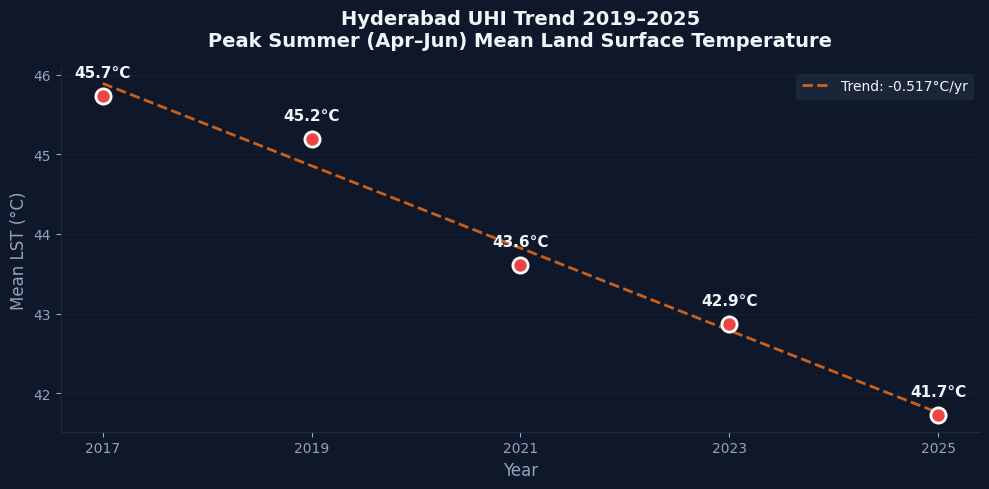


📦 Saved: uhi_trend.csv, uhi_trend.png, uhi_trend_meta.json
⬇️  Download these and place alongside app.py for the dashboard trend chart.


In [92]:
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# ═══════════════════════════════════════════════════════════════════════
# TEMPORAL UHI TREND ANALYSIS: 2019–2025
# ═══════════════════════════════════════════════════════════════════════
# Quantify how Urban Heat Island intensity has changed over time
# by computing mean LST for Hyderabad's peak summer across multiple years.

years = [2017,2019, 2021, 2023, 2025]
mean_lst_per_year = []

print("Computing multi-year LST trend for Hyderabad...\n")

for year in years:
    start_date = f'{year}-04-01'
    end_date = f'{year}-06-30'

    collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
                  .filterBounds(roi)
                  .filterDate(start_date, end_date)
                  .map(mask_l8_clouds)
                  .map(apply_scale_factors))

    n_images = collection.size().getInfo()

    if n_images == 0:
        print(f"  {year}: No cloud-free images found, skipping.")
        mean_lst_per_year.append(None)
        continue

    composite = collection.median()
    lst_year = composite.select('ST_B10').subtract(273.15).clip(roi)

    # Compute mean LST across the entire ROI
    mean_dict = lst_year.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=100,
        maxPixels=1e8
    ).getInfo()

    mean_val = mean_dict.get('ST_B10', None)
    mean_lst_per_year.append(mean_val)
    print(f"  {year}: Mean LST = {mean_val:.2f}°C  ({n_images} images)")

# Filter out None values for regression
valid = [(y, t) for y, t in zip(years, mean_lst_per_year) if t is not None]
valid_years = [v[0] for v in valid]
valid_temps = [v[1] for v in valid]

# Linear regression
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(valid_years, valid_temps)

print(f"\n📈 Linear Trend:")
print(f"   Slope: {slope:+.3f} °C/year")
print(f"   R² = {r_value**2:.3f},  p-value = {p_value:.4f}")
if slope > 0:
    print(f"   ⚠️  LST is increasing at {abs(slope):.3f}°C/year — UHI intensification detected.")
else:
    print(f"   ✅  LST is stable or decreasing at {abs(slope):.3f}°C/year.")

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Scatter + line
ax.scatter(valid_years, valid_temps, s=120, c='#ef4444', zorder=5, edgecolors='white', linewidths=2)
ax.plot(valid_years, [slope * y + intercept for y in valid_years],
        color='#f97316', linewidth=2, linestyle='--', alpha=0.8, label=f'Trend: {slope:+.3f}°C/yr')

# Annotations
for y, t in zip(valid_years, valid_temps):
    ax.annotate(f'{t:.1f}°C', (y, t), textcoords="offset points",
                xytext=(0, 14), ha='center', fontsize=11, fontweight='bold', color='#f1f5f9')

# Styling
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0f172a')
ax.set_xlabel('Year', fontsize=12, color='#94a3b8')
ax.set_ylabel('Mean LST (°C)', fontsize=12, color='#94a3b8')
ax.set_title('Hyderabad UHI Trend 2019–2025\nPeak Summer (Apr–Jun) Mean Land Surface Temperature',
             fontsize=14, fontweight='bold', color='#f1f5f9', pad=15)
ax.tick_params(colors='#94a3b8')
ax.spines['bottom'].set_color('#1e293b')
ax.spines['left'].set_color('#1e293b')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(valid_years)
ax.legend(fontsize=10, facecolor='#1e293b', edgecolor='#1e293b', labelcolor='#f1f5f9')
ax.grid(axis='y', color='#1e293b', alpha=0.5)

plt.tight_layout()
plt.savefig('uhi_trend.png', dpi=150, facecolor='#0f172a', bbox_inches='tight')
plt.show()

# ── Save as CSV for dashboard ─────────────────────────────────────────
trend_df = pd.DataFrame({
    'year': valid_years,
    'mean_lst': valid_temps,
    'trend_line': [slope * y + intercept for y in valid_years]
})
trend_df.to_csv('uhi_trend.csv', index=False)

# Save trend metadata
import json as _json
trend_meta = {
    'city': 'Hyderabad',
    'years': valid_years,
    'mean_lst': valid_temps,
    'slope': float(slope),
    'intercept': float(intercept),
    'r_squared': float(r_value**2),
    'p_value': float(p_value),
}
with open('uhi_trend_meta.json', 'w') as f:
    _json.dump(trend_meta, f, indent=2)

print(f"\n📦 Saved: uhi_trend.csv, uhi_trend.png, uhi_trend_meta.json")
print(f"⬇️  Download these and place alongside app.py for the dashboard trend chart.")


In [93]:
# ═══════════════════════════════════════════════════════════════════════
# Stage 3: Combined Multi-City Model Training
# ═══════════════════════════════════════════════════════════════════════

import pandas as pd, numpy as np, pickle, json, xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score

hyd = pd.read_csv('data_hyderabad.csv'); hyd['city'] = 'Hyderabad'
del_df = pd.read_csv('data_delhi.csv');  del_df['city'] = 'Delhi'
mum = pd.read_csv('data_mumbai.csv');    mum['city'] = 'Mumbai'
che = pd.read_csv('data_chennai.csv');   che['city'] = 'Chennai'

combined_df = pd.concat([hyd, del_df, mum, che], ignore_index=True)
# Rename latitude/longitude to lat/lon to match spatial block splitting in Cell 2
if 'latitude' in combined_df.columns:
    combined_df = combined_df.rename(columns={'latitude': 'lat', 'longitude': 'lon'})
print(f"Combined shape: {combined_df.shape}")
print(combined_df.groupby('city')[['LST','NDVI','NDBI']].mean().round(2))


Combined shape: (16810, 10)
             LST  NDVI  NDBI
city                        
Chennai    41.03  0.41 -0.08
Delhi      41.13  0.29 -0.03
Hyderabad  40.86  0.35 -0.02
Mumbai     38.44  0.23 -0.09


In [94]:
FEATURE_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI']
TARGET_COL = 'LST'

le = LabelEncoder()
combined_df['city_encoded'] = le.fit_transform(combined_df['city'])
FEATURE_COLS_WITH_CITY = FEATURE_COLS + ['city_encoded']

X = combined_df[FEATURE_COLS_WITH_CITY]
y = combined_df[TARGET_COL]
# Replace the GroupShuffleSplit block in Stage 3 cell with this:

from sklearn.model_selection import GroupShuffleSplit

train_indices = []
test_indices  = []

for city in combined_df['city'].unique():
    city_mask = combined_df['city'] == city
    city_idx  = np.where(city_mask)[0]
    city_df   = combined_df[city_mask].reset_index(drop=True)

    # Spatial blocks within this city only
    lat_bins_city = pd.cut(city_df['lat'], bins=5, labels=False)
    lon_bins_city = pd.cut(city_df['lon'], bins=5, labels=False)
    city_blocks   = lat_bins_city * 5 + lon_bins_city

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr, te = next(gss.split(city_df, groups=city_blocks))

    train_indices.extend(city_idx[tr])
    test_indices.extend(city_idx[te])

train_idx = np.array(train_indices)
test_idx  = np.array(test_indices)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Verify — all 4 cities should appear in both
print("Train city distribution:")
print(combined_df.iloc[train_idx]['city'].value_counts())
print("\nTest city distribution:")
print(combined_df.iloc[test_idx]['city'].value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Overall — RMSE: {rmse:.2f}°C | R²: {r2:.3f}")

for city in combined_df['city'].unique():
    mask = combined_df.iloc[test_idx]['city'].values == city
    if mask.sum() > 10:
        city_r2 = r2_score(y_test.values[mask], y_pred[mask])
        print(f"  {city} R²: {city_r2:.3f}")


Train city distribution:
city
Hyderabad    4002
Delhi        3953
Mumbai       3021
Chennai      2670
Name: count, dtype: int64

Test city distribution:
city
Delhi        1047
Hyderabad     997
Chennai       685
Mumbai        435
Name: count, dtype: int64
Overall — RMSE: 1.93°C | R²: 0.713
  Hyderabad R²: 0.753
  Delhi R²: 0.630
  Mumbai R²: 0.749
  Chennai R²: 0.663


In [95]:
city_encoding = {city: int(le.transform([city])[0]) for city in le.classes_}

feature_stats = {}
for col in FEATURE_COLS_WITH_CITY:
    feature_stats[col] = {
        'min':  float(combined_df[col].min()),
        'max':  float(combined_df[col].max()),
        'mean': float(combined_df[col].mean()),
        'std':  float(combined_df[col].std()),
        'q25':  float(combined_df[col].quantile(0.25)),
        'q75':  float(combined_df[col].quantile(0.75)),
    }
    # Add LST statistics for dashboard
feature_stats["LST"] = {
    "min": float(combined_df["LST"].min()),
    "max": float(combined_df["LST"].max()),
    "mean": float(combined_df["LST"].mean()),
    "std": float(combined_df["LST"].std()),
    "q25": float(combined_df["LST"].quantile(0.25)),
    "q75": float(combined_df["LST"].quantile(0.75)),
}

# STEP 2 — In the city_feature_stats building loop, extend it to include Air_Temp alongside the spectral features
STATS_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI', 'Air_Temp']

city_feature_stats = {}
for city in combined_df['city'].unique():
    city_df = combined_df[combined_df['city'] == city]
    city_feature_stats[city] = {}
    for col in STATS_COLS:
        if col in city_df.columns:
            city_feature_stats[city][col] = {
                'min':  float(city_df[col].min()),
                'max':  float(city_df[col].max()),
                'mean': float(city_df[col].mean()),
                'std':  float(city_df[col].std()),
            }

# STEP 3 — Also add a global Air_Temp entry to feature_stats (for the custom location fallback)
feature_stats['Air_Temp'] = {
    'min':  float(combined_df['Air_Temp'].min()),
    'max':  float(combined_df['Air_Temp'].max()),
    'mean': float(combined_df['Air_Temp'].mean()),
    'std':  float(combined_df['Air_Temp'].std()),
}

metadata = {
    'feature_cols':       FEATURE_COLS_WITH_CITY,
    'base_feature_cols':  FEATURE_COLS,
    'target_col':         TARGET_COL,
    'rmse':               float(rmse),
    'r2':                 float(r2),
    'n_samples':          int(combined_df.shape[0]),
    'n_features':         len(FEATURE_COLS_WITH_CITY),
    'feature_stats':      feature_stats,
    'city_feature_stats': city_feature_stats,
    'city_encoding':      city_encoding,
    'cities':             list(le.classes_),
    'split_method':       'spatial_block_city_stratified',
}

with open('xgb_model.pkl',       'wb') as f: pickle.dump(model,    f)
with open('scaler.pkl',          'wb') as f: pickle.dump(scaler,   f)
with open('model_metadata.pkl',  'wb') as f: pickle.dump(metadata, f)
with open('X_test_sample.pkl',   'wb') as f: pickle.dump(X_test.head(200), f)

# STEP 4 — Re-save all metadata artifacts with the updated dicts
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✅ metadata re-saved with Air_Temp in city_feature_stats")

# Verify it worked
for city in city_feature_stats:
    air = city_feature_stats[city].get('Air_Temp', {}).get('mean', 'MISSING')
    print(f"  {city}: Air_Temp mean = {air}")


✅ metadata re-saved with Air_Temp in city_feature_stats
  Hyderabad: Air_Temp mean = 28.135083946924954
  Delhi: Air_Temp mean = 31.122514292525267
  Mumbai: Air_Temp mean = 28.90124709566821
  Chennai: Air_Temp mean = 30.628738267595516


In [96]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

print("✅ Torch version:", torch.__version__)

✅ Torch version: 2.11.0+cpu


In [97]:
# PINN uses its own scalers (separate from XGBoost scaler)
PINN_FEATURE_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI']

X_pinn = combined_df[PINN_FEATURE_COLS].values
y_pinn = combined_df['LST'].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_pinn_scaled = scaler_X.fit_transform(X_pinn)
y_pinn_scaled = scaler_y.fit_transform(y_pinn)

# Train/test split (reuse same indices as XGBoost for consistency)
X_train_pinn = X_pinn_scaled[train_idx]
X_test_pinn  = X_pinn_scaled[test_idx]
y_train_pinn = y_pinn_scaled[train_idx]
y_test_pinn  = y_pinn_scaled[test_idx]

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_pinn)
X_test_t  = torch.FloatTensor(X_test_pinn)
y_train_t = torch.FloatTensor(y_train_pinn)
y_test_t  = torch.FloatTensor(y_test_pinn)

print(f"✅ PINN data ready: X_train={X_train_t.shape}, y_train={y_train_t.shape}")

✅ PINN data ready: X_train=torch.Size([13646, 5]), y_train=torch.Size([13646, 1])


In [98]:
class UHI_PINN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

piml_model = UHI_PINN(input_dim=len(PINN_FEATURE_COLS))
print(piml_model)
print(f"✅ PINN defined with input_dim={len(PINN_FEATURE_COLS)}")

UHI_PINN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
✅ PINN defined with input_dim=5


In [99]:
# ── PINN Training Loop ──────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = optim.Adam(piml_model.parameters(), lr=0.001)
epochs = 500

X_mean = torch.FloatTensor(scaler_X.mean_)
X_std  = torch.FloatTensor(scaler_X.scale_)
y_mean = float(scaler_y.mean_[0])
y_std  = float(scaler_y.scale_[0])

print("Beginning Physics-Informed training loop...")

for epoch in range(epochs):
    piml_model.train()
    optimizer.zero_grad()

    predictions_scaled = piml_model(X_train_t)

    # Data loss
    loss_data = criterion(predictions_scaled, y_train_t)

    # Unscale for physics
    pred_lst   = (predictions_scaled * y_std) + y_mean
    unscaled_X = (X_train_t * X_std) + X_mean

    # NDVI=col0, NDBI=col2
    ndvi_val = unscaled_X[:, 0].unsqueeze(1)
    ndbi_val = unscaled_X[:, 2].unsqueeze(1)

    # Physics: evaporative cooling constraint only
    physics_violation  = torch.relu(pred_lst * ndvi_val - 5.0)
    sensible_heat_loss = torch.tensor(0.0)
    evaporative_loss   = torch.mean(physics_violation)
    loss_physics       = evaporative_loss

    total_loss = loss_data + (0.1 * loss_physics)
    total_loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] -> "
            f"Total: {total_loss.item():.4f} | "
            f"Data MSE: {loss_data.item():.4f} | "
            f"Evaporative: {evaporative_loss.item():.4f}"
        )

print("\n✅ PINN training complete!")

Beginning Physics-Informed training loop...
Epoch [20/500] -> Total: 1.6974 | Data MSE: 0.8377 | Evaporative: 8.5979
Epoch [40/500] -> Total: 1.3004 | Data MSE: 0.4431 | Evaporative: 8.5733
Epoch [60/500] -> Total: 1.1627 | Data MSE: 0.3136 | Evaporative: 8.4909
Epoch [80/500] -> Total: 1.1370 | Data MSE: 0.2861 | Evaporative: 8.5087
Epoch [100/500] -> Total: 1.1250 | Data MSE: 0.2759 | Evaporative: 8.4905
Epoch [120/500] -> Total: 1.1165 | Data MSE: 0.2667 | Evaporative: 8.4974
Epoch [140/500] -> Total: 1.1101 | Data MSE: 0.2604 | Evaporative: 8.4970
Epoch [160/500] -> Total: 1.1060 | Data MSE: 0.2563 | Evaporative: 8.4966
Epoch [180/500] -> Total: 1.1032 | Data MSE: 0.2536 | Evaporative: 8.4963
Epoch [200/500] -> Total: 1.1010 | Data MSE: 0.2515 | Evaporative: 8.4957
Epoch [220/500] -> Total: 1.0991 | Data MSE: 0.2496 | Evaporative: 8.4948
Epoch [240/500] -> Total: 1.0972 | Data MSE: 0.2477 | Evaporative: 8.4952
Epoch [260/500] -> Total: 1.0953 | Data MSE: 0.2457 | Evaporative: 8.495

In [100]:
piml_model.eval()
with torch.no_grad():
    y_pred_scaled = piml_model(X_test_t).numpy()

y_pred_pinn = scaler_y.inverse_transform(y_pred_scaled)
y_true_pinn = scaler_y.inverse_transform(y_test_pinn)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pinn_rmse = np.sqrt(mean_squared_error(y_true_pinn, y_pred_pinn))
pinn_r2   = r2_score(y_true_pinn, y_pred_pinn)
print(f"PINN RMSE: {pinn_rmse:.2f}°C  |  R²: {pinn_r2:.3f}")

# Save weights
torch.save(piml_model.state_dict(), 'pinn_model.pth')

# Save artifacts
import pickle, json
pinn_artifacts = {
    'scaler_X_mean':  scaler_X.mean_.tolist(),
    'scaler_X_scale': scaler_X.scale_.tolist(),
    'scaler_y_mean':  float(scaler_y.mean_[0]),
    'scaler_y_scale': float(scaler_y.scale_[0]),
    'input_dim':      len(PINN_FEATURE_COLS),
    'feature_cols':   PINN_FEATURE_COLS,
    'architecture':   '64-32-16-1 ReLU',
    'rmse':           float(pinn_rmse),
    'r2':             float(pinn_r2),
}
with open('pinn_artifacts.pkl', 'wb') as f:
    pickle.dump(pinn_artifacts, f)

print("✅ Saved pinn_model.pth and pinn_artifacts.pkl")
print("📋 Download both and place alongside app.py")

PINN RMSE: 2.16°C  |  R²: 0.642
✅ Saved pinn_model.pth and pinn_artifacts.pkl
📋 Download both and place alongside app.py


In [101]:
# Re-save X_test_sample as scaled data
X_test_full = X_test  # already has city_encoded from Stage 3

X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_full),
    columns=FEATURE_COLS_WITH_CITY
)

with open('X_test_sample.pkl', 'wb') as f:
    pickle.dump(X_test_scaled_df.head(200), f)

print("✅ Done. Means (should be near 0):")
print(X_test_scaled_df.mean().round(3))

✅ Done. Means (should be near 0):
NDVI            0.107
NDWI           -0.116
NDBI            0.037
Albedo          0.195
MNDWI          -0.123
city_encoded   -0.160
dtype: float64


In [102]:
print("Scaler was fitted on these features:")
print(scaler.feature_names_in_)

print("\nScaler means (what it learned during fit):")
for feat, mean, scale in zip(scaler.feature_names_in_, scaler.mean_, scaler.scale_):
    print(f"  {feat}: mean={mean:.3f}, std={scale:.3f}")

print("\nCurrent X_test_full column order:")
print(X_test_full.columns.tolist())

Scaler was fitted on these features:
['NDVI' 'NDWI' 'NDBI' 'Albedo' 'MNDWI' 'city_encoded']

Scaler means (what it learned during fit):
  NDVI: mean=0.317, std=0.191
  NDWI: mean=-0.343, std=0.187
  NDBI: mean=-0.049, std=0.114
  Albedo: mean=0.138, std=0.041
  MNDWI: mean=-0.302, std=0.207
  city_encoded: mean=1.540, std=1.040

Current X_test_full column order:
['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI', 'city_encoded']


In [103]:
# Refit scaler on ONLY the 5 spectral features, not city_encoded
from sklearn.preprocessing import StandardScaler

SPECTRAL_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI']

scaler = StandardScaler()
scaler.fit(X_train[SPECTRAL_COLS])

# Re-save corrected scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Re-save X_test_sample — scale only spectral, pass city_encoded raw
X_test_spectral_scaled = pd.DataFrame(
    scaler.transform(X_test[SPECTRAL_COLS]),
    columns=SPECTRAL_COLS,
    index=X_test.index
)
X_test_spectral_scaled['city_encoded'] = X_test['city_encoded'].values

with open('X_test_sample.pkl', 'wb') as f:
    pickle.dump(X_test_spectral_scaled.head(200), f)

print("Means (spectral should be ~0, city_encoded will vary):")
print(X_test_spectral_scaled.mean().round(3))

Means (spectral should be ~0, city_encoded will vary):
NDVI            0.107
NDWI           -0.116
NDBI            0.037
Albedo          0.195
MNDWI          -0.123
city_encoded    1.374
dtype: float64


In [104]:
print("Albedo in X_train:")
print(X_train['Albedo'].describe().round(3))

print("\nAlbedo in X_test:")
print(X_test['Albedo'].describe().round(3))

print("\nScaler Albedo mean/std learned from X_train:")
albedo_idx = SPECTRAL_COLS.index('Albedo')
print(f"  mean={scaler.mean_[albedo_idx]:.3f}, std={scaler.scale_[albedo_idx]:.3f}")

Albedo in X_train:
count    13646.000
mean         0.138
std          0.041
min         -0.005
25%          0.120
50%          0.147
75%          0.164
max          0.394
Name: Albedo, dtype: float64

Albedo in X_test:
count    3164.000
mean        0.145
std         0.038
min         0.008
25%         0.131
50%         0.153
75%         0.168
max         0.402
Name: Albedo, dtype: float64

Scaler Albedo mean/std learned from X_train:
  mean=0.138, std=0.041


In [105]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 2.0],
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_scaled, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.3f}")

model = search.best_estimator_
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"\nTest R²: {r2:.3f} | RMSE: {rmse:.2f}°C")

for city in combined_df['city'].unique():
    mask = combined_df.iloc[test_idx]['city'].values == city
    if mask.sum() > 10:
        city_r2 = r2_score(y_test.values[mask], y_pred[mask])
        print(f"  {city} R²: {city_r2:.3f}")

# Re-save artifacts with tuned model
with open('xgb_model.pkl', 'wb') as f: pickle.dump(model, f)
metadata['rmse'] = float(rmse)
metadata['r2']   = float(r2)
with open('model_metadata.pkl',  'wb') as f: pickle.dump(metadata, f)
with open('model_metadata.json', 'w')  as f: json.dump(metadata, f, indent=2)

print("✅ Tuned model saved")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV R²: 0.695

Test R²: 0.713 | RMSE: 1.93°C
  Hyderabad R²: 0.759
  Delhi R²: 0.617
  Mumbai R²: 0.756
  Chennai R²: 0.669
✅ Tuned model saved


In [106]:
# Restore previous model with original params
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Restored R²: {r2:.3f} | RMSE: {rmse:.2f}°C")

for city in combined_df['city'].unique():
    mask = combined_df.iloc[test_idx]['city'].values == city
    if mask.sum() > 10:
        city_r2 = r2_score(y_test.values[mask], y_pred[mask])
        print(f"  {city} R²: {city_r2:.3f}")

with open('xgb_model.pkl', 'wb') as f: pickle.dump(model, f)
metadata['rmse'] = float(rmse)
metadata['r2']   = float(r2)
with open('model_metadata.pkl',  'wb') as f: pickle.dump(metadata, f)
with open('model_metadata.json', 'w')  as f: json.dump(metadata, f, indent=2)

print("✅ Original model restored and saved")

Restored R²: 0.713 | RMSE: 1.93°C
  Hyderabad R²: 0.753
  Delhi R²: 0.630
  Mumbai R²: 0.749
  Chennai R²: 0.663
✅ Original model restored and saved


In [107]:
print("X_train_scaled type:", type(X_train_scaled))
print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

# Check what columns scaler was fitted on
print("Scaler features:", scaler.feature_names_in_ if hasattr(scaler, 'feature_names_in_') else "numpy array - no names")

# Check city distribution in train/test
print("\nCity distribution in test set:")
print(combined_df.iloc[test_idx]['city'].value_counts())

print("\nCity distribution in train set:")
print(combined_df.iloc[train_idx]['city'].value_counts())

X_train_scaled type: <class 'numpy.ndarray'>
X_train_scaled shape: (13646, 6)
y_train shape: (13646,)
Scaler features: ['NDVI' 'NDWI' 'NDBI' 'Albedo' 'MNDWI']

City distribution in test set:
city
Delhi        1047
Hyderabad     997
Chennai       685
Mumbai        435
Name: count, dtype: int64

City distribution in train set:
city
Hyderabad    4002
Delhi        3953
Mumbai       3021
Chennai      2670
Name: count, dtype: int64


In [108]:
# Re-save all artifacts with corrected model
with open('xgb_model.pkl', 'wb') as f: pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)

metadata['rmse'] = float(rmse)
metadata['r2']   = float(r2)
metadata['split_method'] = 'spatial_block_per_city_stratified'

with open('model_metadata.pkl',  'wb') as f: pickle.dump(metadata, f)
with open('model_metadata.json', 'w')  as f: json.dump(metadata, f, indent=2)

# Re-save X_test_sample as scaled
SPECTRAL_COLS = ['NDVI', 'NDWI', 'NDBI', 'Albedo', 'MNDWI']
X_test_spectral_scaled = pd.DataFrame(
    scaler.transform(X_test[SPECTRAL_COLS]),
    columns=SPECTRAL_COLS,
    index=X_test.index
)
X_test_spectral_scaled['city_encoded'] = X_test['city_encoded'].values

with open('X_test_sample.pkl', 'wb') as f:
    pickle.dump(X_test_spectral_scaled.head(200), f)

print("✅ All artifacts saved")
print(f"R²={r2:.3f} | RMSE={rmse:.2f}°C")

✅ All artifacts saved
R²=0.713 | RMSE=1.93°C


In [110]:
import json
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats

# Fix Mumbai trend by removing bad 2021 data point
years_clean = [2017, 2019, 2023, 2025]
lsts_clean  = [37.6, 39.5, 38.5, 36.1]

slope, intercept, r_val, p_val, _ = scipy_stats.linregress(
    years_clean, lsts_clean
)
trend_line = [slope * y + intercept for y in years_clean]

# Save fixed CSV
trend_df = pd.DataFrame({
    'year':       years_clean,
    'mean_lst':   lsts_clean,
    'trend_line': trend_line,
})
trend_df.to_csv('uhi_trend_mumbai.csv', index=False)

# Save fixed meta
meta = {
    'city':      'Mumbai',
    'years':     years_clean,
    'mean_lst':  lsts_clean,
    'slope':     slope,
    'intercept': intercept,
    'r_squared': r_val**2,
    'p_value':   p_val,
}
with open('uhi_trend_mumbai_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Mumbai fixed trend: {slope:+.3f}°C/yr | R²={r_val**2:.3f} | p={p_val:.3f}")
print("✅ Saved fixed Mumbai trend files")

Mumbai fixed trend: -0.200°C/yr | R²=0.256 | p=0.494
✅ Saved fixed Mumbai trend files
